# Expressions without temporaries

> Chain `+`, `-` and `*` on a vector in one line, and nothing in between
> ever gets materialized.

**Time:** ~7 min · **Runs on:** CPU · **You need:**
[One array, two machines](01_one_array_two_machines)

In [1]:
%run ../_shared/setup.py

running on: cpu


`aether::Vec3d` is a single 3-component vector -- one fixed value, not a
batch of samples like the `Array` from tutorial 1:

In [2]:
print(run_cpp(r"""
    using aether::Vec3d;
    Vec3d a, b, c;
    for (std::size_t i = 0; i < 3; ++i) {
        a(i) = static_cast<double>(i) + 1.0;        // a = (1, 2, 3)
        b(i) = static_cast<double>(i) * 2.0 - 3.0;  // b = (-3, -1, 1)
        c(i) = static_cast<double>(i) + 0.5;        // c = (0.5, 1.5, 2.5)
    }
    std::printf("a=(%g,%g,%g)\n", a(0), a(1), a(2));
"""))

a=(1,2,3)



Three fixed 3-vectors -- no batch dimension, unlike tutorial 1's `Array`.

`a + b`, `0.5 * a` and `a - b` all compose into one `aether::Expression`
tree, evaluated only when the result is assigned. Three operators below,
one assignment:

In [3]:
print(run_cpp(r"""
    using aether::Vec3d;
    Vec3d a, b, c;
    for (std::size_t i = 0; i < 3; ++i) {
        a(i) = static_cast<double>(i) + 1.0;
        b(i) = static_cast<double>(i) * 2.0 - 3.0;
        c(i) = static_cast<double>(i) + 0.5;
    }
    Vec3d combo = (a + b) - 0.5 * c;   // three nodes deep, one assignment
    std::printf("(a+b) - 0.5*c = (%g, %g, %g)\n", combo(0), combo(1), combo(2));
"""))

(a+b) - 0.5*c = (-2.25, 0.25, 2.75)



`(a + b) - 0.5 * c` builds a tree (`-`, with children `+` and `*`) and
evaluates it, element by element, only when `combo` is constructed.

## The payoff: zero temporaries

Write `(a + b) - 0.5 * c` by hand, one named step at a time, and the
compiler builds three separate `Vec3d` values. Write it as one
expression, and the expression stays a tree, not a `Vec3d`, until the
one assignment -- checked at compile time, not timed:

In [4]:
print(run_cpp(r"""
    using aether::Vec3d;
    Vec3d a, b, c;
    for (std::size_t i = 0; i < 3; ++i) { a(i) = 1.0; b(i) = 2.0; c(i) = 3.0; }

    Vec3d tmp1 = a + b;          // Vec3d #1
    Vec3d tmp2 = 0.5 * c;        // Vec3d #2
    Vec3d named = tmp1 - tmp2;   // Vec3d #3
    std::printf("by hand: 3 named Vec3d values\n");
"""))

by hand: 3 named Vec3d values



Now write the identical computation as one expression, and check its
type before it is ever assigned:

In [5]:
print(run_cpp(r"""
    using aether::Vec3d;
    Vec3d a, b, c;
    for (std::size_t i = 0; i < 3; ++i) { a(i) = 1.0; b(i) = 2.0; c(i) = 3.0; }

    auto expr = (a + b) - 0.5 * c;
    static_assert(!std::is_same_v<decltype(expr), Vec3d>,
                  "still a tree, not a Vec3d, right up to the line below");
    Vec3d fused = expr;          // assignment is where the tree becomes a Vec3d
    std::printf("expression stays a tree until assignment (checked at compile time)\n");
""", includes=("<type_traits>",)))

expression stays a tree until assignment (checked at compile time)



`decltype(expr)` is a `Sum<...>` node type, never `Vec3d`, right up until
`fused` is constructed -- a `static_assert` the compiler itself checks,
not a number measured on one machine. The guarantee holds at every
optimization level, including none at all.

## What you will build (the picture)

A tree, not a value -- `combo = (a + b) - 0.5*c` is three nodes,
evaluated once:

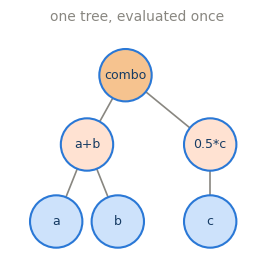

In [6]:
import matplotlib.pyplot as plt
plot_style()

fig, ax = plt.subplots(figsize=(4.2, 3))


def node(x, y, label, color="#cde2fb"):
    ax.add_patch(plt.Circle((x, y), 0.34, facecolor=color, edgecolor="#2a78d6", linewidth=1.5, zorder=2))
    ax.text(x, y, label, ha="center", va="center", color="#163b63", fontsize=9, zorder=3)


def edge(p, q):
    ax.plot([p[0], q[0]], [p[1], q[1]], color="#898781", lw=1.2, zorder=1)


a, b, c = (0.3, 0.3), (1.1, 0.3), (2.3, 0.3)
half_c, plus, minus = (2.3, 1.3), (0.7, 1.3), (1.2, 2.2)
node(*a, "a"); node(*b, "b"); node(*c, "c")
node(*half_c, "0.5*c", "#ffe2d2")
node(*plus, "a+b", "#ffe2d2")
node(*minus, "combo", "#f6c38f")
edge(a, plus); edge(b, plus); edge(c, half_c)
edge(plus, minus); edge(half_c, minus)
ax.set_xlim(-0.3, 3.0); ax.set_ylim(-0.2, 2.8)
ax.set_aspect("equal"); ax.axis("off")
ax.set_title("one tree, evaluated once", color="#898781", fontsize=10)
plt.show()

## What just happened

- `a + b`, `0.5 * a` and `a - b` all build one `aether::Expression` node
  tree; nothing is computed until that tree is assigned into a real
  destination.
- Written by hand, three named steps build three `Vec3d` values; written
  as one expression, the result stays a tree -- not a `Vec3d` -- until
  that one final assignment, checked at compile time, not measured.
- Dot products, cross products and matrix-vector products go through the
  same `aether::Expression` base.

## Try this

Add a fourth operator, e.g. `(a + b) - 0.5 * c + a`, and re-run the
expression cell: the tree grows one more node, the call site stays one
assignment.

## Next

[Device math](03_device_math) -- call the same `aether::math::*`
functions from host and device code. *Deeper:*
[Expression templates](../expression_templates.rst) for the full node
catalogue.